# Análisis de Checklists - Adaptación de Textos

Este notebook realiza un análisis comparativo de los checklists de cumplimiento para diferentes herramientas de adaptación de textos, basándose en los datos del archivo `comparacion.xlsx`.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from decimal import Decimal

# Configuración de visualización
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga de Datos

Cargamos la hoja principal para obtener los nombres de las herramientas y luego iteramos por las hojas numeradas (1-N) para extraer los checklists detallados.

In [46]:
file_path = 'comparacion_capa2.xlsx'

# Leer la matriz comparativa para obtener los nombres de las herramientas
df_matriz = pd.read_excel(file_path, sheet_name='Matriz comparativa')

# Las herramientas están en las columnas a partir de la cuarta (índice 3)
tool_names = df_matriz.columns[3:].tolist()
print(f"Herramientas encontradas: {len(tool_names)}")
print(tool_names)

Herramientas encontradas: 11
['FACILE', 'Placea', 'Asistente de lectura fácil “ANTONIO GONZALES CRESPO”', 'Asistente de lectura fácil “Mark Jonathan Camacho Escatel”: ', 'Gemini 3.1 Pro', 'GPT 5.4 Think', 'Claude Sonnet 4.6', 'deepseek-v3.2', 'SimpleText (ClearText)', 'Modelo_Qwen3.5_9B', 'Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"']


In [47]:
# Diccionario para almacenar los checklists de cada herramienta
checklists = {}

for i, tool in enumerate(tool_names):
    sheet_name = str(i + 2)
    try:
        # Leer la hoja numerada correspondiente
        df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Limpiar datos: nos interesan las filas que tienen un ítem de verificación
        # (normalmente hasta la fila 18-19, antes del total)
        df_clean = df_sheet.dropna(subset=['Ítem de Validación'])
        df_clean = df_clean[df_clean['Ítem de Validación'] != 'Total Cumplidos']
        
        # Guardar en el diccionario
        checklists[tool] = df_clean
    except Exception as e:
        print(f"Error cargando la hoja {sheet_name} para la herramienta {tool}: {e}")

print("Checklists cargados correctamente.")

Checklists cargados correctamente.


## 2. Consolidación de Datos

Creamos un DataFrame maestro donde cada fila es un ítem del checklist y cada columna es una herramienta.

In [48]:
# Obtener la lista base de ítems (usando la primera herramienta como referencia)
base_items = checklists[tool_names[0]][['Epígrafe', 'Ítem de Validación']].copy()
base_items['Epígrafe'] = base_items['Epígrafe'].ffill() # Rellenar categorías vacías

# Crear el DataFrame maestro
df_master = base_items.copy()

for tool in tool_names:
    if tool in checklists:
        # Extraer la columna de cumplimiento
        # 1.0 = SÍ, 0.5 = PARCIAL, 0.0 = NO
        compliance = checklists[tool]['Cumple'].values
        
        # Asegurar que la longitud coincida (por si acaso)
        if len(compliance) == len(df_master):
            df_master[tool] = pd.to_numeric(pd.Series(compliance), errors='coerce').fillna(0).values
        else:
            # Si hay diferencia, mapeamos por nombre de ítem para seguridad
            tool_data = checklists[tool].set_index('Ítem de Validación')['Cumple']
            df_master[tool] = df_master['Ítem de Validación'].map(tool_data)
            df_master[tool] = pd.to_numeric(df_master[tool], errors='coerce').fillna(0)

df_master.head()

,Epígrafe,Ítem de Validación,FACILE,Placea,Asistente de lectura fácil “ANTONIO GONZALES CRESPO”,Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,Gemini 3.1 Pro,GPT 5.4 Think,Claude Sonnet 4.6,deepseek-v3.2,SimpleText (ClearText),Modelo_Qwen3.5_9B,"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez"""
0,Título,Identificación clara del bloque informativo.,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
1,Responsable,Identidad de la entidad que trata los datos.,1.0,1.0,1.0,0.5,1.0,1.0,1.0,1.0,1.0,1.0,0.5
2,Finalidad,Descripción de los fines del tratamiento.,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,1.0,0.5
3,Legitimación,Base jurídica aplicable al tratamiento.,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
4,Destinatarios,Previsión de cesiones o transferencias.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Análisis de Cumplimiento

### Puntaje Total por Herramienta

C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_21392\3534789803.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_totals, x='Items Cumplidos', y='Herramienta', palette='viridis')


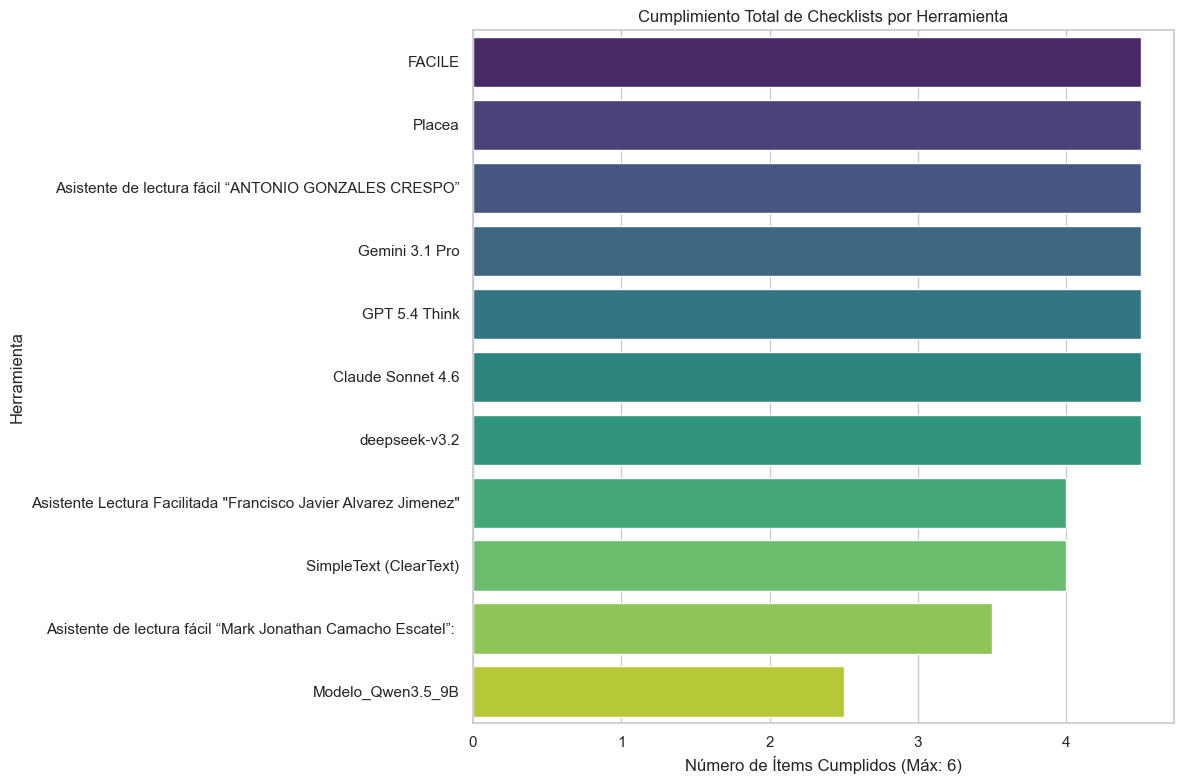

In [49]:
totals = df_master[tool_names].sum().sort_values(ascending=False)
df_totals = pd.DataFrame({'Herramienta': totals.index, 'Items Cumplidos': totals.values})
df_totals['Porcentaje'] = (df_totals['Items Cumplidos'] / len(df_master)) * 100

NUM_ITEMS_CHECKLIST = len(df_master)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_totals, x='Items Cumplidos', y='Herramienta', palette='viridis')
plt.title('Cumplimiento Total de Checklists por Herramienta')
plt.xlabel(f'Número de Ítems Cumplidos (Máx: {NUM_ITEMS_CHECKLIST})')
plt.ylabel('Herramienta')
plt.tight_layout()
plt.show()

In [50]:
df_totals_checker = totals.to_frame(name='Items Cumplidos')
df_totals_checker["Cumplimiento"] = df_totals_checker['Items Cumplidos'].apply(lambda x: np.round((x/NUM_ITEMS_CHECKLIST)*100,3))
df_totals_checker.set_index(df_totals_checker.index, inplace=True)
df_totals_checker.to_excel("totales_checkers.xlsx", index=True)
display(df_totals_checker)


,Items Cumplidos,Cumplimiento
FACILE,4.5,75.000
Placea,4.5,75.000
Asistente de lectura fácil “ANTONIO GONZALES CRESPO”,4.5,75.000
Gemini 3.1 Pro,4.5,75.000
GPT 5.4 Think,4.5,75.000
Claude Sonnet 4.6,4.5,75.000
deepseek-v3.2,4.5,75.000
"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez""",4.0,66.667
SimpleText (ClearText),4.0,66.667
Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,3.5,58.333


### Heatmap de Cumplimiento Detallado

Este mapa permite ver exactamente qué puntos falla cada herramienta.

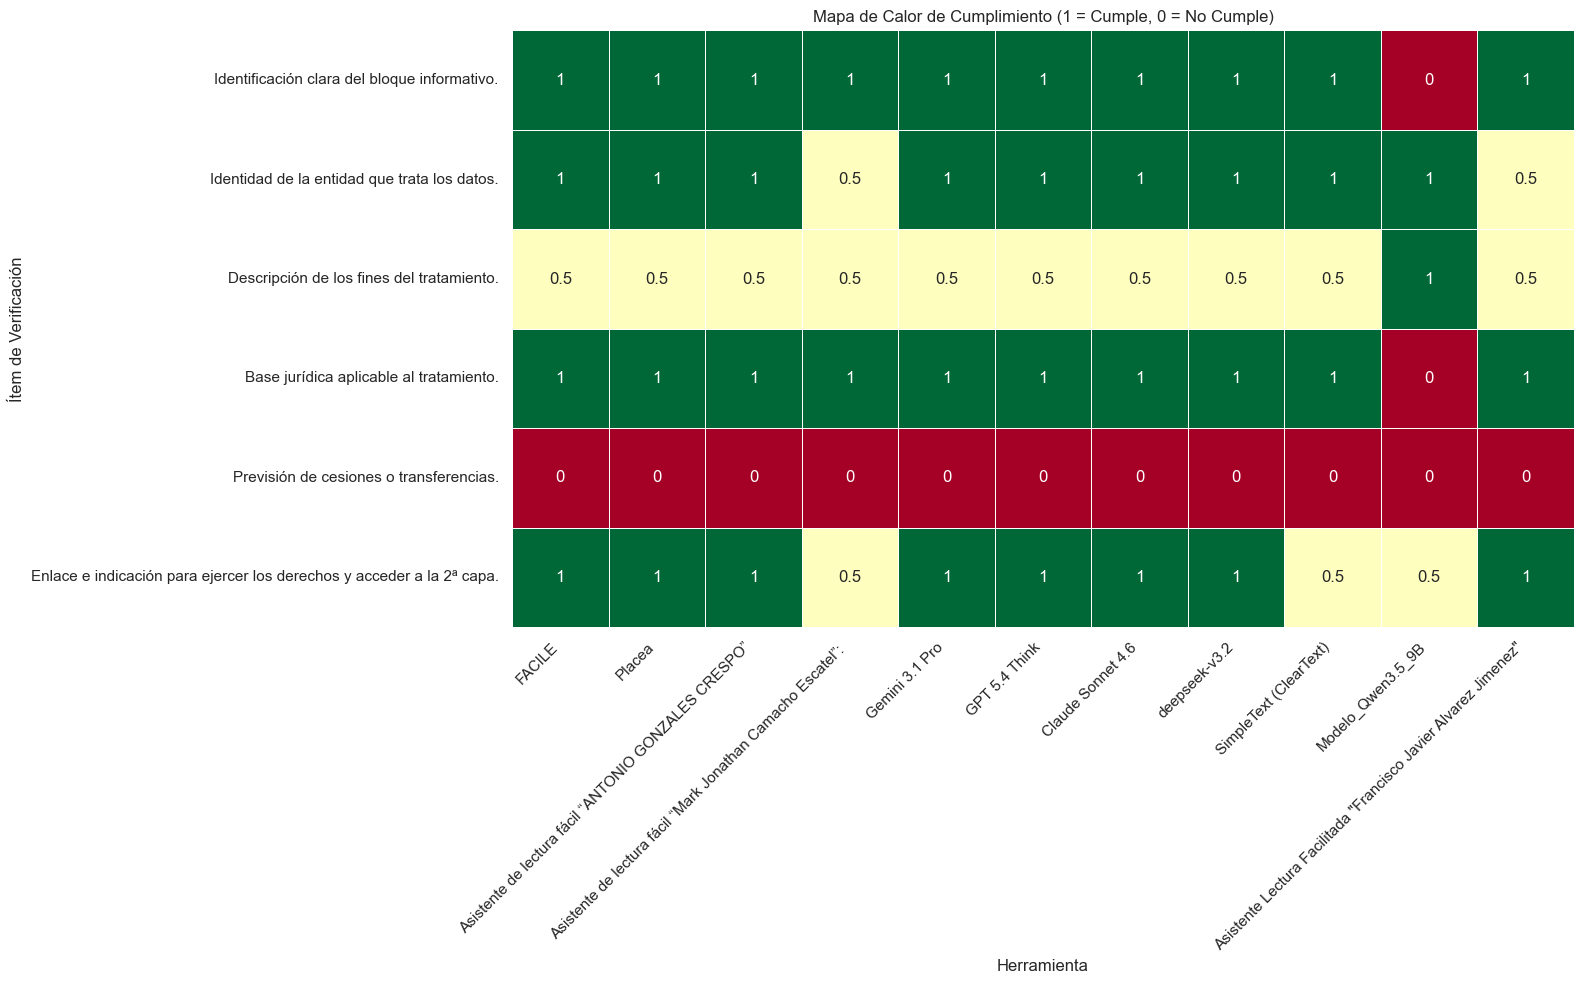

In [51]:
plt.figure(figsize=(16, 10))
heatmap_data = df_master.set_index('Ítem de Validación')[tool_names]
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', cbar=False, linewidths=.5)
plt.title('Mapa de Calor de Cumplimiento (1 = Cumple, 0 = No Cumple)')
plt.ylabel('Ítem de Verificación')
plt.xlabel('Herramienta')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Items que mas se incumplen

In [52]:
columns = ["Epígrafe", "Ítem de Validación",	]

df_master["Total Incumplimiento"] = df_master.apply(
                                    lambda x: x.drop(columns).count() - x.drop(columns).sum()
                                    , axis=1
                                    )
df_master[["Epígrafe", "Ítem de Validación", "Total Incumplimiento"]].sort_values(by="Total Incumplimiento", ascending = False)

,Epígrafe,Ítem de Validación,Total Incumplimiento
4,Destinatarios,Previsión de cesiones o transferencias.,11.0
2,Finalidad,Descripción de los fines del tratamiento.,5.0
5,Derechos,Enlace e indicación para ejercer los derechos ...,1.5
0,Título,Identificación clara del bloque informativo.,1.0
1,Responsable,Identidad de la entidad que trata los datos.,1.0
3,Legitimación,Base jurídica aplicable al tratamiento.,1.0


### Análisis por Categoría

Agrupamos los resultados para ver qué secciones legales o de contenido son las más descuidadas.

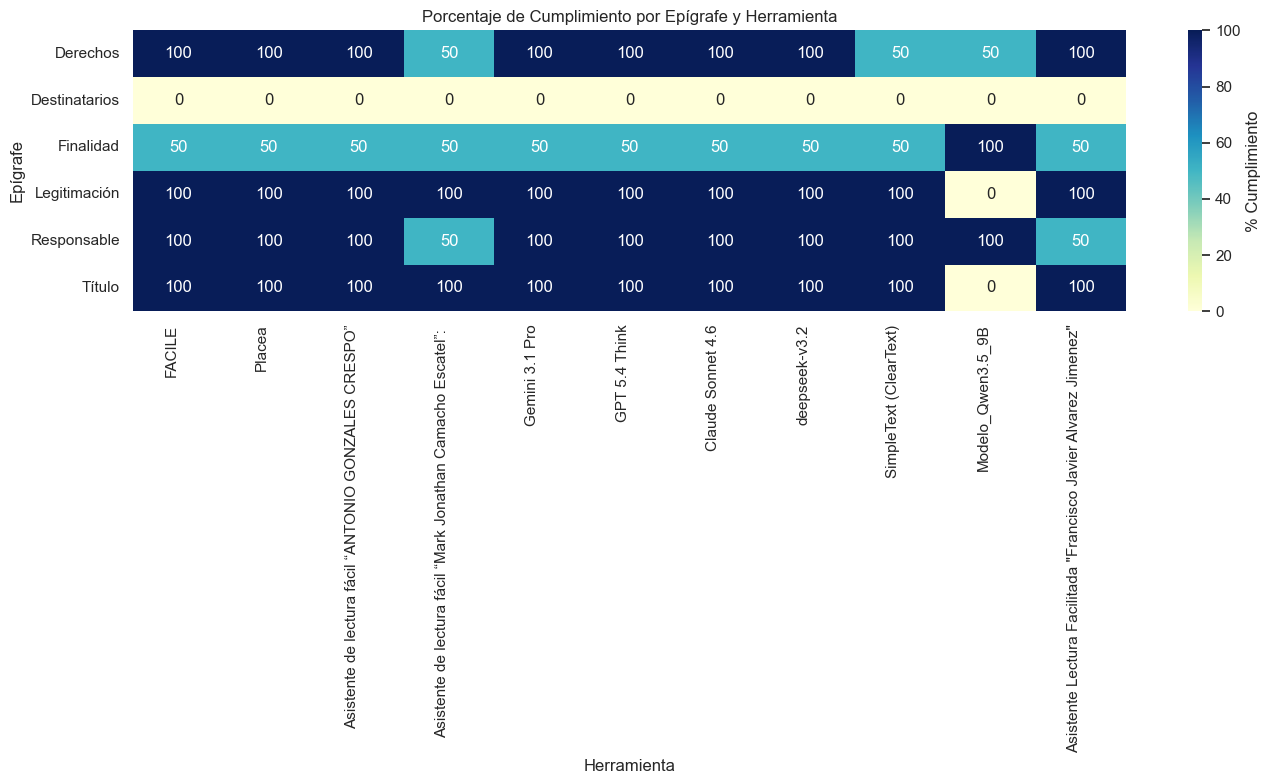

In [53]:
df_cat = df_master.groupby('Epígrafe')[tool_names].mean() * 100

plt.figure(figsize=(14, 8))
sns.heatmap(df_cat, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': '% Cumplimiento'})
plt.title('Porcentaje de Cumplimiento por Epígrafe y Herramienta')
plt.ylabel('Epígrafe')
plt.xlabel('Herramienta')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

## 4. Tablas de Resumen Detallado

A continuación se presentan las tablas de cumplimiento total, parcial e incumplimiento para cada herramienta e ítem.

In [54]:
### Puntaje Detallado por Herramienta

# Calcular totales por tipo de cumplimiento
summary_list = []
for tool in tool_names:
    counts = df_master[tool].value_counts()
    summary_list.append({
        'Herramienta': tool,
        'Cumple (1)': int(counts.get(1.0, 0)),
        'Parcial (0.5)': int(counts.get(0.5, 0)),
        'No cumple (0)': int(counts.get(0.0, 0))
    })

df_resumen = pd.DataFrame(summary_list)
df_resumen

,Herramienta,Cumple (1),Parcial (0.5),No cumple (0)
0,FACILE,4,1,1
1,Placea,4,1,1
2,Asistente de lectura fácil “ANTONIO GONZALES C...,4,1,1
3,Asistente de lectura fácil “Mark Jonathan Cama...,2,3,1
4,Gemini 3.1 Pro,4,1,1
5,GPT 5.4 Think,4,1,1
6,Claude Sonnet 4.6,4,1,1
7,deepseek-v3.2,4,1,1
8,SimpleText (ClearText),3,2,1
9,Modelo_Qwen3.5_9B,2,1,3


In [55]:
### Matriz Detallada por Ítem y Herramienta

# Función para dar formato visual
def format_compliance(val):
    if val == 1.0: return 'SI'
    if val == 0.5: return 'PARCIAL'
    return 'NO'

df_visual = df_master.copy()
for tool in tool_names:
    df_visual[tool] = df_visual[tool].apply(format_compliance)

df_visual

,Epígrafe,Ítem de Validación,FACILE,Placea,Asistente de lectura fácil “ANTONIO GONZALES CRESPO”,Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,Gemini 3.1 Pro,GPT 5.4 Think,Claude Sonnet 4.6,deepseek-v3.2,SimpleText (ClearText),Modelo_Qwen3.5_9B,"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez""",Total Incumplimiento
0,Título,Identificación clara del bloque informativo.,SI,SI,SI,SI,SI,SI,SI,SI,SI,NO,SI,1.0
1,Responsable,Identidad de la entidad que trata los datos.,SI,SI,SI,PARCIAL,SI,SI,SI,SI,SI,SI,PARCIAL,1.0
2,Finalidad,Descripción de los fines del tratamiento.,PARCIAL,PARCIAL,PARCIAL,PARCIAL,PARCIAL,PARCIAL,PARCIAL,PARCIAL,PARCIAL,SI,PARCIAL,5.0
3,Legitimación,Base jurídica aplicable al tratamiento.,SI,SI,SI,SI,SI,SI,SI,SI,SI,NO,SI,1.0
4,Destinatarios,Previsión de cesiones o transferencias.,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,11.0
5,Derechos,Enlace e indicación para ejercer los derechos ...,SI,SI,SI,PARCIAL,SI,SI,SI,SI,PARCIAL,PARCIAL,SI,1.5
